In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path="/content/drive/MyDrive/shopify stocks.csv"

In [4]:
import pandas as pd
df = pd.read_csv(file_path)
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 Rows:")
display(df.head())

Shape: (2469, 7)

Columns:
Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')

Data Types:
date          object
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object

First 5 Rows:


,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [6]:
print(df.isnull().sum())

date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64


In [9]:
price_columns = ['open', 'high', 'low', 'close', 'volume']
for column in price_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

In [10]:
df = df.dropna(subset=price_columns)

In [14]:
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df = df.dropna(subset=['date'])
df = df.sort_values('date')
df = df.reset_index(drop=True)
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 04:00:00+00:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 04:00:00+00:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 04:00:00+00:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 04:00:00+00:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 04:00:00+00:00,2.755,2.774,2.648,2.745,2.745,4000000


In [15]:
df['Daily_Delta'] = df['close'] - df['open']

In [17]:
print(df[['date', 'open', 'close', 'Daily_Delta']].head())

                       date   open  close  Daily_Delta
0 2015-05-21 04:00:00+00:00  2.800  2.568       -0.232
1 2015-05-22 04:00:00+00:00  2.607  2.831        0.224
2 2015-05-26 04:00:00+00:00  2.980  2.965       -0.015
3 2015-05-27 04:00:00+00:00  3.067  2.750       -0.317
4 2015-05-28 04:00:00+00:00  2.755  2.745       -0.010


In [19]:
df['Daily_Return'] = df['close'].pct_change() * 100

In [21]:
print(df[['date', 'open', 'close', 'Daily_Delta', 'Daily_Return']].head())

                       date   open  close  Daily_Delta  Daily_Return
0 2015-05-21 04:00:00+00:00  2.800  2.568       -0.232           NaN
1 2015-05-22 04:00:00+00:00  2.607  2.831        0.224     10.241433
2 2015-05-26 04:00:00+00:00  2.980  2.965       -0.015      4.733303
3 2015-05-27 04:00:00+00:00  3.067  2.750       -0.317     -7.251262
4 2015-05-28 04:00:00+00:00  2.755  2.745       -0.010     -0.181822


In [22]:
print(df[['date', 'close', 'Daily_Return']].head())

                       date  close  Daily_Return
0 2015-05-21 04:00:00+00:00  2.568           NaN
1 2015-05-22 04:00:00+00:00  2.831     10.241433
2 2015-05-26 04:00:00+00:00  2.965      4.733303
3 2015-05-27 04:00:00+00:00  2.750     -7.251262
4 2015-05-28 04:00:00+00:00  2.745     -0.181822


In [25]:
print(df.columns.tolist())

['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'Daily_Delta', 'Daily_Return']


In [26]:
average_volume = df['volume'].mean()
print("Average Trading Volume:", average_volume)

Average Trading Volume: 16570491.778047793


In [29]:
df['Volume_MA_20'] = df['volume'].rolling(20).mean()
print(df[['date', 'volume', 'Volume_MA_20']].head(25))

                        date     volume  Volume_MA_20
0  2015-05-21 04:00:00+00:00  123039000           NaN
1  2015-05-22 04:00:00+00:00   28412000           NaN
2  2015-05-26 04:00:00+00:00    8202000           NaN
3  2015-05-27 04:00:00+00:00    7976000           NaN
4  2015-05-28 04:00:00+00:00    4000000           NaN
5  2015-05-29 04:00:00+00:00    2554000           NaN
6  2015-06-01 04:00:00+00:00    2569000           NaN
7  2015-06-02 04:00:00+00:00    3798000           NaN
8  2015-06-03 04:00:00+00:00    3024000           NaN
9  2015-06-04 04:00:00+00:00    3226000           NaN
10 2015-06-05 04:00:00+00:00    1294000           NaN
11 2015-06-08 04:00:00+00:00    2809000           NaN
12 2015-06-09 04:00:00+00:00    3375000           NaN
13 2015-06-10 04:00:00+00:00    2734000           NaN
14 2015-06-11 04:00:00+00:00    4606000           NaN
15 2015-06-12 04:00:00+00:00    8474000           NaN
16 2015-06-15 04:00:00+00:00   16943000           NaN
17 2015-06-16 04:00:00+00:00

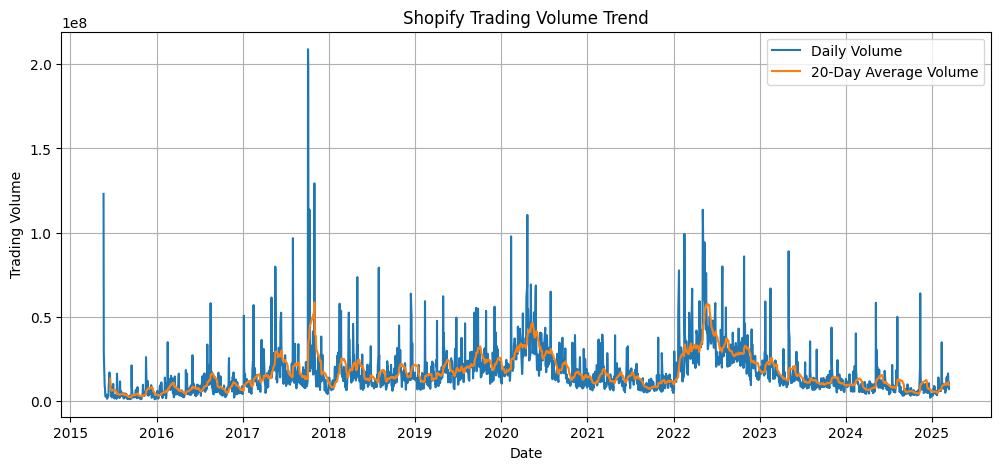

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df['date'], df['volume'], label='Daily Volume')
plt.plot(df['date'], df['Volume_MA_20'], label='20-Day Average Volume')

plt.title('Shopify Trading Volume Trend')
plt.xlabel('Date')
plt.ylabel('Trading Volume')

plt.legend()
plt.grid()

plt.show()

In [31]:
volume_mean = df['volume'].mean()
volume_std = df['volume'].std()

print("Average Trading Volume:", volume_mean)
print("Volume Standard Deviation:", volume_std)

Average Trading Volume: 16570491.778047793
Volume Standard Deviation: 14369091.49927283


In [32]:
high_volume_days = df[
    df['volume'] > volume_mean + 2 * volume_std
]

print("Anomalous Trading Days:")

display(
    high_volume_days[
        ['date', 'close', 'volume']
    ]
)

Anomalous Trading Days:


,date,close,volume
0,2015-05-21 04:00:00+00:00,2.568000,123039000
313,2016-08-17 04:00:00+00:00,3.874000,58113000
410,2017-01-05 05:00:00+00:00,4.768000,50702000
438,2017-02-15 05:00:00+00:00,6.061000,56969000
490,2017-05-02 04:00:00+00:00,8.298000,61484000
...,...,...,...
1949,2023-02-16 05:00:00+00:00,44.910000,66831900
2002,2023-05-04 04:00:00+00:00,57.299999,88927300
2256,2024-05-08 04:00:00+00:00,62.730000,58311600
2318,2024-08-07 04:00:00+00:00,63.889999,49976600


In [33]:
print("Number of Anomalous Trading Days:", len(high_volume_days))

Number of Anomalous Trading Days: 87


In [34]:
returns = df['Daily_Return'].dropna()

print("Mean Return:", returns.mean())
print("Variance:", returns.var())
print("Standard Deviation:", returns.std())

Mean Return: 0.2148062655694457
Variance: 13.78075206243252
Standard Deviation: 3.712243534903458


In [35]:
print(df['Daily_Return'].describe())

count    2468.000000
mean        0.214806
std         3.712244
min       -18.585338
25%        -1.663313
50%         0.203627
75%         2.058009
max        23.838337
Name: Daily_Return, dtype: float64


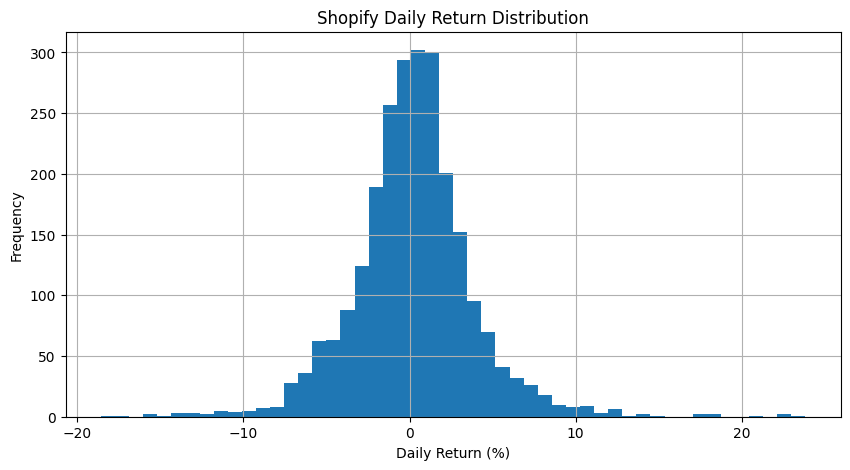

In [36]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['Daily_Return'].dropna(),
    bins=50
)

plt.title('Shopify Daily Return Distribution')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')

plt.grid()

plt.show()

In [37]:
print("Final Dataset:")

display(df.head())

Final Dataset:


,date,open,high,low,close,adj_close,volume,Daily_Delta,Daily_Return,Volume_MA_20
0,2015-05-21 04:00:00+00:00,2.800,2.874,2.411,2.568,2.568,123039000,-0.232,NaN,NaN
1,2015-05-22 04:00:00+00:00,2.607,3.110,2.600,2.831,2.831,28412000,0.224,10.241433,NaN
2,2015-05-26 04:00:00+00:00,2.980,3.034,2.908,2.965,2.965,8202000,-0.015,4.733303,NaN
3,2015-05-27 04:00:00+00:00,3.067,3.081,2.700,2.750,2.750,7976000,-0.317,-7.251262,NaN
4,2015-05-28 04:00:00+00:00,2.755,2.774,2.648,2.745,2.745,4000000,-0.010,-0.181822,NaN


In [38]:
print("Rows and Columns:")

print(df.shape)

Rows and Columns:
(2469, 10)


In [39]:
print("Missing Values:")

print(df.isnull().sum())

Missing Values:
date             0
open             0
high             0
low              0
close            0
adj_close        0
volume           0
Daily_Delta      0
Daily_Return     1
Volume_MA_20    19
dtype: int64
